# Training Data Feature Engineering + Clustering

In [1]:
# ---- Imports ---- #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
BASE_PATH = os.path.dirname(os.getcwd()) # Current Runtime location

DATA_PATH_TRAIN = os.path.join(BASE_PATH, "data", "train_data.csv")


folders = [
    "Pipelines",
    "Preprocessing",
    os.path.join("Preprocessing", "Features"),
    "Cluster Datasets"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)


In [3]:
# ---- Seeding ---- #
np.random.seed(42)
random.seed(42)

In [4]:
# ---- Loading Data ---- #
train = pd.read_csv(DATA_PATH_TRAIN)

print(train.shape)
# train.head()
train.info()
# train.describe()

(5807, 97)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5807 entries, 0 to 5806
Data columns (total 97 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Index                                                     5807 non-null   int64  
 1   Bankrupt?                                                 5807 non-null   int64  
 2    ROA(C) before interest and depreciation before interest  5807 non-null   float64
 3    ROA(A) before interest and % after tax                   5807 non-null   float64
 4    ROA(B) before interest and depreciation after tax        5807 non-null   float64
 5    Operating Gross Margin                                   5807 non-null   float64
 6    Realized Sales Gross Margin                              5807 non-null   float64
 7    Operating Profit Rate                                    5807 non-null   float64
 8    Pre-ta

In [5]:
# ---- CLUSTER START ---- #
# ---- set Target y & setup input X---- #
train["Bankrupt?"].value_counts() # to see the split of companies bankrupt
y = train["Bankrupt?"]
X = train.drop(columns=["Bankrupt?", "Index"])
#X.info()
#X.shape

In [6]:
# ---- Preliminary Feature Analysis ---- #
corr = X.corr().abs()
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs.sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.head(20)

Debt ratio %                          Net worth/Assets                        1.000000
Net worth/Assets                      Debt ratio %                            1.000000
Operating Gross Margin                Gross Profit to Sales                   1.000000
Gross Profit to Sales                 Operating Gross Margin                  1.000000
Net Value Per Share (C)               Net Value Per Share (A)                 0.999820
Net Value Per Share (A)               Net Value Per Share (C)                 0.999820
Realized Sales Gross Margin           Operating Gross Margin                  0.999504
Operating Gross Margin                Realized Sales Gross Margin             0.999504
Gross Profit to Sales                 Realized Sales Gross Margin             0.999504
Realized Sales Gross Margin           Gross Profit to Sales                   0.999504
Net Value Per Share (A)               Net Value Per Share (B)                 0.999256
Net Value Per Share (B)               Net V

It seems the dataset is full of ratios that use some of the same base numbers. Such as Debt Ratio = Networth / Assets. For Feature reduction might be a good idea to just drop one of them and keep the other. To start, I would drop anything over 0.95.

In [7]:
# ---- Correlation Trimming ---- #
threshold = 0.95
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
) # Look at the upper triangle and drop the highest.

to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Number of features to drop:", len(to_drop))
to_drop[:10]

dropped_info = []

for col in upper.columns:
    high_corr = upper[col][upper[col] > threshold]
    if len(high_corr) > 0:
        for idx, val in high_corr.items():
            dropped_info.append((col, idx, val))

dropped_df = pd.DataFrame(dropped_info, columns=["Dropped_Feature", "Correlated_With", "Correlation"])

DROPPED_FEATURES_PATH = os.path.join(BASE_PATH, "Preprocessing", "Features", "DroppedFeatures.csv")
dropped_df.to_csv(DROPPED_FEATURES_PATH, index=False)

dropped_df.head(10)
X_reduced = X.drop(columns=to_drop)
print("New shape:", X_reduced.shape)


Number of features to drop: 17
New shape: (5807, 78)


We went down from 95 features to 78 features. I'll try to run a PCA to see the best number of features to go with for this dataset, strictly for the visual and to get a good idea for number of features (Like how much below 50)

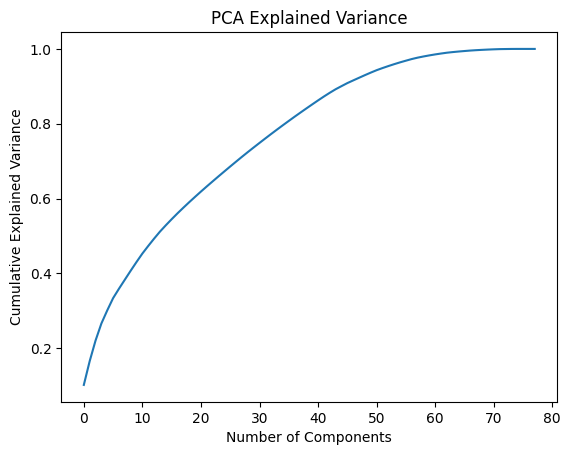

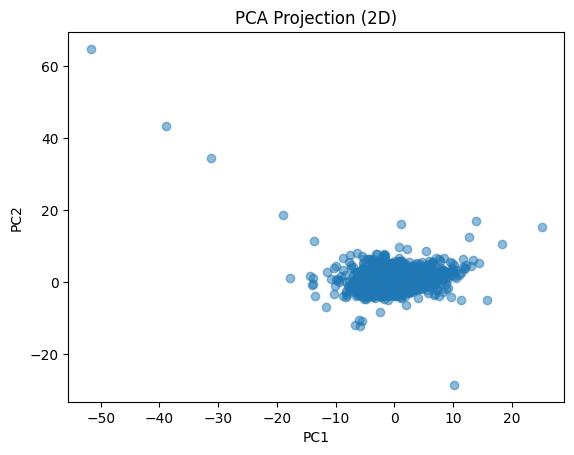

In [8]:
# ---- PCA Dimension Visuals ---- #
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], alpha=0.5)
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Looking at the first graph, the explained variance gets very good at around 60+. But since our goal is to use 50<, we will end up losing quite a bit of signal. My first opinion is not to drop too far below 45, aiming for around 40-50 features to maintain +80% signal, with 50 being somewhat optimal.  The second graph, this is a bit of a messy blob, there are some outliers that are scattered but it mostly has a dense area in the middle, suggesting that our clustering won't be easy but challenging us as it has some structure and will be useful.

Clustering is appropriate as the dataset exhibits underlying structure, as shown in PCA projections. The resulting clusters demonstrate significantly different bankruptcy rates and financial characteristics, there is some meaningful segmentation here.

To see which of these features seem important, we can do a random forest and see if the features can be ranked by importance.

In [9]:
# ---- Random Forest Classification ---- #
rf = RandomForestClassifier(random_state=42)
rf.fit(X_reduced, y)
importances = pd.Series(rf.feature_importances_, index=X_reduced.columns)
importances = importances.sort_values(ascending=False)
importances.head(20)

Net Value Growth Rate                                      0.037147
Net Income to Stockholder's Equity                         0.033629
Borrowing dependency                                       0.029182
Persistent EPS in the Last Four Seasons                    0.027273
Total debt/Total net worth                                 0.024734
Equity to Liability                                        0.023854
Retained Earnings to Total Assets                          0.020696
Net Value Per Share (B)                                    0.020539
Non-industry income and expenditure/revenue                0.020333
ROA(C) before interest and depreciation before interest    0.019852
Interest Expense Ratio                                     0.019837
Debt ratio %                                               0.018779
Quick Ratio                                                0.018750
Interest Coverage Ratio (Interest expense to EBIT)         0.018168
Cash/Total Assets                               

Looks like our target, Bankruptcy, was pushed by things such as Net Value Growth Rate, Net Income to Equity, Borrowing/Leverage. This fits because bankruptcy would be driven by a companies ability to pull debt, make profit margins, and have liquid assets available.

In [10]:
top_features = importances.head(50).index
X_final = X_reduced[top_features]

print(X_final.shape)
FINAL50_FULL_FEATURES_PATH = os.path.join(BASE_PATH, "Preprocessing", "Features", "Final50Features_Full.csv")
FINAL50_NAMES_FEATURES_PATH = os.path.join(BASE_PATH, "Preprocessing", "Features", "Final50Features_Names.csv")

# Save full dataset (with values)
X_final.to_csv(FINAL50_FULL_FEATURES_PATH, index=False)

# Save just feature names
pd.DataFrame(top_features, columns=["Feature"]).to_csv(
    FINAL50_NAMES_FEATURES_PATH,
    index=False
)

(5807, 50)


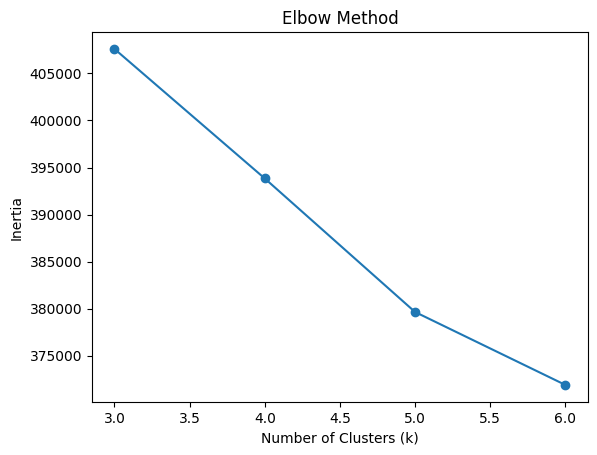

k=3, silhouette=0.1137
k=4, silhouette=0.1140
k=5, silhouette=0.1003
k=6, silhouette=0.0876


In [11]:
# ---- K Means Clustering Prep ---- #
inertia = []
k_values = range(3, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

for k in range(3, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.4f}")

Based on the elbow method and silhouette scores, k=4 was selected. While k=3 is valid, k=4 provides slightly better separation. Additionally, clustering results align well with bankruptcy distributions, producing meaningful subgroup structures. Any higher than 4 and there looks to be a drop in cluster quality.

In [12]:
# ---- K Means Clustering: K = 4 ---- #
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

###  Preventing outliers from skewing K ###
X_clipped = X_final.copy()

for col in X_clipped.columns:
    lower = X_clipped[col].quantile(0.01)
    upper = X_clipped[col].quantile(0.99)
    X_clipped[col] = X_clipped[col].clip(lower, upper)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

clusters = kmeans.fit_predict(X_scaled)

# Attach clusters
train_clustered = train.copy()
train_clustered["Cluster"] = clusters

# Count companies in each Cluster
train_clustered["Cluster"].value_counts()
train_clustered.groupby("Cluster")["Bankrupt?"].value_counts()
train_clustered.groupby("Cluster")["Bankrupt?"].mean()

Cluster
0    0.000000
1    0.017839
2    0.002554
3    0.151003
Name: Bankrupt?, dtype: float64

In [13]:
# Safety Check to ensure Target was not included in Input
"Bankrupt?" in X_final.columns

False

In [14]:
for i in range(num_clusters):
    cluster_df = train_clustered[train_clustered["Cluster"] == i]

    cluster_path = os.path.join(
        BASE_PATH,
        "Cluster Datasets",
        f"cluster_{i}.csv"
    )

    cluster_df.to_csv(cluster_path, index=False)

In [15]:
# ARTIFACTS
# Saving pipeline/joblib

PIPELINES_PATH = os.path.join(BASE_PATH, "Pipelines")
os.makedirs(PIPELINES_PATH, exist_ok=True)

# ---- Save clipping bounds ---- #
clip_bounds = {}

for col in X_final.columns:
    lower = X_final[col].quantile(0.01)
    upper = X_final[col].quantile(0.99)
    clip_bounds[col] = {"lower": lower, "upper": upper}

joblib.dump(
    clip_bounds,
    os.path.join(PIPELINES_PATH, "clip_bounds.pkl")
)

# ---- Save selected feature names ---- #
joblib.dump(
    list(X_final.columns),
    os.path.join(PIPELINES_PATH, "selected_features.pkl")
)

# ---- Save preprocessing pipeline ---- #
preprocess_pipeline = Pipeline([
    ("scaler", scaler)
])

joblib.dump(
    preprocess_pipeline,
    os.path.join(PIPELINES_PATH, "preprocess_pipeline.pkl")
)

# ---- Save fitted KMeans ---- #
joblib.dump(
    kmeans,
    os.path.join(PIPELINES_PATH, "kmeans_model.pkl")
)

['c:\\Users\\NRagh\\Desktop\\Bankruptcy Prediction\\Pipelines\\kmeans_model.pkl']

In [16]:
# Cluster Sumamry
cluster_summary = train_clustered.groupby("Cluster").agg(
    num_companies=("Bankrupt?", "count"),
    num_bankrupt=("Bankrupt?", "sum"),
    bankruptcy_rate=("Bankrupt?", "mean")
)

cluster_summary

,num_companies,num_bankrupt,bankruptcy_rate
Cluster,,,
0,1106,0,0.000000
1,2971,53,0.017839
2,783,2,0.002554
3,947,143,0.151003


- Cluster 0 contains 0% bankrupt companies and is therefore treated as a constant predictor (always predicting 0), as allowed in Section 3.2 of the project guidelines.

- Cluster 1 has a low to moderate signal to bankruptcy.
- Cluster 2 has a weak signal to bankruptcy.
- Cluster 3 has a high signal to bankruptcy.

In [17]:
cluster_features = train_clustered.groupby("Cluster")[X_final.columns].mean()
cluster_features.head()

,Net Value Growth Rate,Net Income to Stockholder's Equity,Borrowing dependency,Persistent EPS in the Last Four Seasons,Total debt/Total net worth,Equity to Liability,Retained Earnings to Total Assets,Net Value Per Share (B),Non-industry income and expenditure/revenue,ROA(C) before interest and depreciation before interest,...,Revenue Per Share (Yuan ¥),Operating Profit Rate,Quick Asset Turnover Rate,Allocation rate per person,Continuous Net Profit Growth Rate,Total expense/Assets,Inventory and accounts receivable/Net value,Revenue per person,Operating Profit Growth Rate,Cash Flow Per Share
Cluster,,,,,,,,,,,,,,,,,,,,,
0,8.362982e-04,0.843649,0.371431,0.270403,4.830605e-03,0.051662,0.952691,0.226195,0.303793,0.579675,...,5.904158e-02,0.999164,1.604346e+09,9.186257e+06,0.218453,0.024418,0.400906,4.828508e-02,0.848369,0.334779
1,4.821305e-04,0.841260,0.375131,0.226138,8.259102e-03,0.033486,0.937064,0.187310,0.303759,0.503769,...,1.016493e+06,0.999008,2.823287e+09,1.501851e+07,0.217649,0.024279,0.403636,3.781645e-02,0.848283,0.321475
2,5.567681e-04,0.840694,0.370057,0.222353,3.741252e+07,0.117765,0.933964,0.186268,0.303556,0.499065,...,1.928480e+06,0.998890,4.588927e+08,1.136654e+07,0.217583,0.038691,0.397530,1.906484e-02,0.847990,0.322980
3,1.127772e+07,0.833704,0.380301,0.194868,1.576471e-02,0.029956,0.909054,0.164918,0.303454,0.429109,...,2.392407e-02,0.997192,2.108099e+09,1.380486e+07,0.216775,0.041668,0.403742,7.444562e+06,0.846493,0.317456


- Cluster 0 is our predictor cluster, there are no bankruptcies observed. Companies in this pool are financially stable.

- Cluster 1 appears to have a pretty high debt ratio, low cash/assets, and less profitability. These are likely moderate risk companies that are taking on more debt and are not as liquid.

- Cluster 2 has strongly leveraged companies with very low liquidity as shown by their quick ratio. They have almost half of their cash made up of current year liabilities. Being extremely leveraged does mean they are fragile but it does not mean that they often fail, thus explaining a low bankruptcy count.


- Cluster 3 has the highest Debt Ratio and lowest profitability. These are high debt companies that typically fall into bankruptcy. This group has distressed companies.

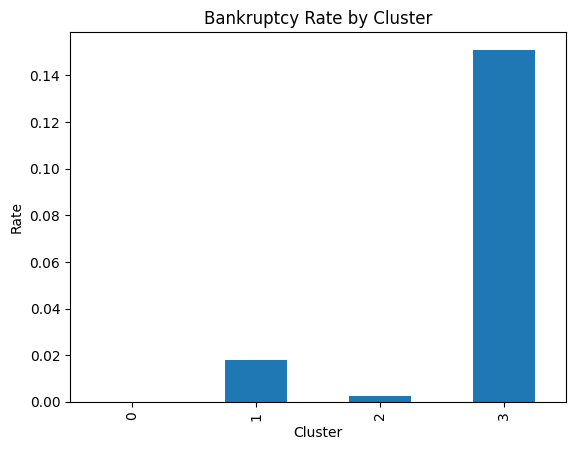

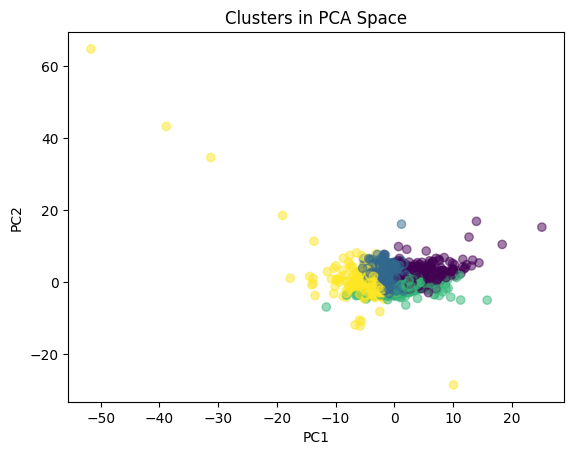

In [18]:
# Visualizations

## Bankruptcy Rate by Cluster
cluster_summary["bankruptcy_rate"].plot(kind="bar")
plt.title("Bankruptcy Rate by Cluster")
plt.ylabel("Rate")
plt.show()

## Clusters in PCA Space
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, alpha=0.5)
plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Final Cluster Assignments

After clustering the training data, the subgroups were assigned as follows for subgroup bankruptcy prediction.

In [19]:
# ============================================================
# FINAL CLUSTER ASSIGNMENTS
# ============================================================

cluster_assignments = pd.DataFrame([
    {
        "Cluster ID": 0,
        "Training Companies": 1106,
        "Bankrupt Companies": 0,
        "Bankruptcy Rate": "0.00%",
        "Model Responsibility": "Constant prediction: Bankrupt? = 0"
    },
    {
        "Cluster ID": 1,
        "Training Companies": 2971,
        "Bankrupt Companies": 53,
        "Bankruptcy Rate": f"{53 / 2971:.2%}",
        "Model Responsibility": "Cluster 1 subgroup bankruptcy model"
    },
    {
        "Cluster ID": 2,
        "Training Companies": 783,
        "Bankrupt Companies": 2,
        "Bankruptcy Rate": f"{2 / 783:.2%}",
        "Model Responsibility": "Cluster 2 subgroup bankruptcy model"
    },
    {
        "Cluster ID": 3,
        "Training Companies": 947,
        "Bankrupt Companies": 143,
        "Bankruptcy Rate": f"{143 / 947:.2%}",
        "Model Responsibility": "Cluster 3 subgroup bankruptcy model"
    }
])

display(cluster_assignments)

,Cluster ID,Training Companies,Bankrupt Companies,Bankruptcy Rate,Model Responsibility
0,0,1106,0,0.00%,Constant prediction: Bankrupt? = 0
1,1,2971,53,1.78%,Cluster 1 subgroup bankruptcy model
2,2,783,2,0.26%,Cluster 2 subgroup bankruptcy model
3,3,947,143,15.10%,Cluster 3 subgroup bankruptcy model


Cluster 0 contained no bankrupt companies in the training data, so it was assigned a constant non-bankrupt prediction. Clusters 1, 2, and 3 were assigned to individual team members for subgroup-specific stacking models.

# Table 3 Results

In [20]:
# ------------------------------------------------------------
# TABLE 3: Result Table
# Required columns:
# Subgroup ID, Name of Student, Number Companies,
# Number Bankrupt, Stacking Model TT, Stacking Model TF, Nfeatures
# ------------------------------------------------------------

table3_results = pd.DataFrame([
    {
        "Subgroup ID": 0,
        "Number Companies": 1106,
        "Number Bankrupt": 0,
        "Stacking Model TT": 0,
        "Stacking Model TF": 0,
        "Nfeatures": 0
    },
    {
        "Subgroup ID": 1,
        "Number Companies": 2971,
        "Number Bankrupt": 53,
        "Stacking Model TT": 45,
        "Stacking Model TF": 8,
        "Nfeatures": 20
    },
    {
        "Subgroup ID": 2,
        "Number Companies": 783,
        "Number Bankrupt": 2,
        "Stacking Model TT": 2,
        "Stacking Model TF": 0,
        "Nfeatures": 50
    },
    {
        "Subgroup ID": 3,
        "Number Companies": 947,
        "Number Bankrupt": 143,
        "Stacking Model TT": 138,
        "Stacking Model TF": 5,
        "Nfeatures": 20
    }
])

display(table3_results)

,Subgroup ID,Number Companies,Number Bankrupt,Stacking Model TT,Stacking Model TF,Nfeatures
0,0,1106,0,0,0,0
1,1,2971,53,45,8,20
2,2,783,2,2,0,50
3,3,947,143,138,5,20


In [21]:
# ------------------------------------------------------------
# TABLE 3 TEAM TOTAL ROW
# Last row sums companies, bankrupt, TT, TF.
# ------------------------------------------------------------

weighted_nfeatures = (
    (table3_results["Number Companies"] * table3_results["Nfeatures"]).sum()
    / table3_results["Number Companies"].sum()
)

team_row = pd.DataFrame([{
    "Subgroup ID": "Team 10",
    "Number Companies": int(table3_results["Number Companies"].sum()),
    "Number Bankrupt": int(table3_results["Number Bankrupt"].sum()),
    "Stacking Model TT": int(table3_results["Stacking Model TT"].sum()),
    "Stacking Model TF": int(table3_results["Stacking Model TF"].sum()),
    "Nfeatures": "50"
}])

table3_with_total = pd.concat([table3_results, team_row], ignore_index=True)

display(table3_with_total)

,Subgroup ID,Number Companies,Number Bankrupt,Stacking Model TT,Stacking Model TF,Nfeatures
0,0,1106,0,0,0,0
1,1,2971,53,45,8,20
2,2,783,2,2,0,50
3,3,947,143,138,5,20
4,Team 10,5807,198,185,13,50


Team Total Nfeatures reflects the shared 50-feature reduced space used for clustering and routing before subgroup-specific modeling.